### Required Discussion 19:1: Building a Recommender System with SURPRISE

This discussion focuses on exploring additional algorithms with the `Suprise` library to generate recommendations.  Your goal is to identify the optimal algorithm by minimizing the mean squared error using cross validation. You are also going to select a dataset to use from [grouplens](https://grouplens.org/datasets/movielens/) example datasets.  

To begin, head over to [grouplens](https://grouplens.org/datasets/movielens/) and examine the different datasets available.  Choose one so that it is easy to create the data as expected in `Surprise` with user, item, and rating information.  Then, compare the performance of at least the `KNNBasic`, `SVD`, `NMF`, `SlopeOne`, and `CoClustering` algorithms to build your recommendations.  For more information on the algorithms see the documentation for the algorithm package [here](https://surprise.readthedocs.io/en/stable/prediction_algorithms_package.html).

Share the results of your investigation and include the results of your cross validation and a basic description of your dataset with your peers.


In [1]:
from surprise import Dataset, Reader, SVD, NMF, KNNBasic, SlopeOne, CoClustering, BaselineOnly
from surprise.model_selection import cross_validate

import pandas as pd

In [2]:
import pandas as pd
from pathlib import Path

data_dir = Path("./data_release")

datasets = [
    "movie_elicitation_set.csv",
    "movies.csv",
    "user_rating_history.csv",
    "ratings_for_additional_users.csv",
    "user_recommendation_history.csv",
    "belief_data.csv",
]

for fname in datasets:
    path = data_dir / fname
    print("=" * 100)
    print(f"DATASET: {fname}")
    print(f"Path: {path}")
    
    try:
        df = pd.read_csv(path)
        
        print("\n--- head(5) ---")
        display(df.head(5))
        
        print("\n--- info() ---")
        df.info()
        
    except Exception as e:
        print(f"⚠️ Failed to load {fname}: {e}")


DATASET: movie_elicitation_set.csv
Path: data_release/movie_elicitation_set.csv

--- head(5) ---


,movieId,month_idx,source,tstamp
0,1,0,1,2023-02-27 19:30:03
1,1,1,1,2023-04-01 00:01:47
2,1,2,1,2023-05-01 00:02:01
3,1,3,1,2023-06-01 00:01:40
4,1,4,1,2023-07-01 00:01:56



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84058 entries, 0 to 84057
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   movieId    84058 non-null  int64 
 1   month_idx  84058 non-null  int64 
 2   source     84058 non-null  int64 
 3   tstamp     84058 non-null  object
dtypes: int64(3), object(1)
memory usage: 2.6+ MB
DATASET: movies.csv
Path: data_release/movies.csv

--- head(5) ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105071 entries, 0 to 105070
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   movieId  105071 non-null  int64 
 1   title    105071 non-null  object
 2   genres   104629 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.4+ MB
DATASET: user_rating_history.csv
Path: data_release/user_rating_history.csv

--- head(5) ---


...


--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185688 entries, 0 to 4185687
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
 3   tstamp   object 
dtypes: float64(1), int64(2), object(1)
memory usage: 127.7+ MB
DATASET: user_recommendation_history.csv
Path: data_release/user_recommendation_history.csv

--- head(5) ---


,userId,tstamp,movieId,predictedRating
0,377084,1677651051,296,4.626386
1,377084,1677651051,55820,4.343642
2,377084,1677651051,924,4.303385
3,377084,1677651051,1732,4.255416
4,377084,1677651051,1258,4.241269



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1285664 entries, 0 to 1285663
Data columns (total 4 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   userId           1285664 non-null  int64  
 1   tstamp           1285664 non-null  int64  
 2   movieId          1285664 non-null  int64  
 3   predictedRating  1285664 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 39.2 MB
DATASET: belief_data.csv
Path: data_release/belief_data.csv

--- head(5) ---


,userId,movieId,isSeen,watchDate,userElicitRating,userPredictRating,userCertainty,tstamp,movie_idx,source,systemPredictRating
0,53982,1,-1,NaN,-1.0,-1.0,-1,2023-05-01 18:59:04,2,2,4.447851
1,56737,1,-1,NaN,-1.0,-1.0,-1,2023-10-08 13:52:36,7,1,3.576154
2,57704,1,-1,NaN,-1.0,-1.0,-1,2023-12-21 19:02:56,9,1,4.252710
3,58881,1,-1,NaN,-1.0,-1.0,-1,2023-06-22 23:31:47,3,2,3.702018
4,58881,1,-1,NaN,-1.0,-1.0,-1,2023-12-31 19:33:33,9,2,3.709682



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004084 entries, 0 to 3004083
Data columns (total 11 columns):
 #   Column               Dtype  
---  ------               -----  
 0   userId               int64  
 1   movieId              int64  
 2   isSeen               int64  
 3   watchDate            object 
 4   userElicitRating     float64
 5   userPredictRating    float64
 6   userCertainty        int64  
 7   tstamp               object 
 8   movie_idx            int64  
 9   source               int64  
 10  systemPredictRating  float64
dtypes: float64(3), int64(6), object(2)
memory usage: 252.1+ MB


### Baseline: 4 columns (with timestamp) vs 3 columns (timestamp eliminated)

We load `user_rating_history` with **all 4 columns** (userId, movieId, rating, tstamp), run the baseline, then **drop the timestamp column** and run the baseline again on the same rows to compare fit time and test time.

In [3]:
import pandas as pd
import numpy as np
from surprise import Dataset, Reader, BaselineOnly
from surprise.model_selection import cross_validate

# Load with ALL 4 columns (userId, movieId, rating, tstamp)
df_4col = pd.read_csv(
    "./data_release/user_rating_history.csv",
    usecols=["userId", "movieId", "rating", "tstamp"]
)
df_4col = df_4col.dropna(subset=["rating"])
df_4col["userId"] = df_4col["userId"].astype(np.int64)
df_4col["movieId"] = df_4col["movieId"].astype(np.int64)

# Same filtering as main notebook: keep users/items with at least 5 ratings
min_ratings = 5
user_counts = df_4col["userId"].value_counts()
movie_counts = df_4col["movieId"].value_counts()
df_4col = df_4col[
    df_4col["userId"].isin(user_counts[user_counts >= min_ratings].index) &
    df_4col["movieId"].isin(movie_counts[movie_counts >= min_ratings].index)
].copy()

print(f"Data with 4 columns (incl. tstamp): {len(df_4col):,} rows, columns: {list(df_4col.columns)}")

reader = Reader(rating_scale=(0.5, 5.0))
bsl_options = {"method": "als", "n_epochs": 5, "reg_u": 12, "reg_i": 5}

# ---- Baseline 1: all 4 columns in DataFrame (Surprise still uses only userId, movieId, rating)
data_4col = Dataset.load_from_df(df_4col[["userId", "movieId", "rating"]], reader)
cv_4col = cross_validate(BaselineOnly(bsl_options=bsl_options), data_4col, measures=["RMSE", "MAE"], cv=5, verbose=True)
fit_mean_4 = np.nanmean(cv_4col["fit_time"])
test_mean_4 = np.nanmean(cv_4col["test_time"])
rmse_mean_4 = np.nanmean(cv_4col["test_rmse"])
mae_mean_4 = np.nanmean(cv_4col["test_mae"])

# ---- Eliminate timestamp column: same data, 3 columns only
df_3col = df_4col.drop(columns=["tstamp"])
print(f"\nData with timestamp eliminated (3 columns): {len(df_3col):,} rows, columns: {list(df_3col.columns)}")

# ---- Baseline 2: 3 columns only
data_3col = Dataset.load_from_df(df_3col[["userId", "movieId", "rating"]], reader)
cv_3col = cross_validate(BaselineOnly(bsl_options=bsl_options), data_3col, measures=["RMSE", "MAE"], cv=5, verbose=True)
fit_mean_3 = np.nanmean(cv_3col["fit_time"])
test_mean_3 = np.nanmean(cv_3col["test_time"])
rmse_mean_3 = np.nanmean(cv_3col["test_rmse"])
mae_mean_3 = np.nanmean(cv_3col["test_mae"])

# ---- Comparison
print("\n" + "=" * 70)
print("Comparison: 4 columns (with tstamp) vs 3 columns (tstamp eliminated)")
print("=" * 70)
print(f"{'Metric':<25} {'4 columns':>15} {'3 columns':>15}")
print("-" * 55)
print(f"{'Mean fit time (s)':<25} {fit_mean_4:>15.4f} {fit_mean_3:>15.4f}")
print(f"{'Mean test time (s)':<25} {test_mean_4:>15.4f} {test_mean_3:>15.4f}")
print(f"{'Mean RMSE':<25} {rmse_mean_4:>15.4f} {rmse_mean_3:>15.4f}")
print(f"{'Mean MAE':<25} {mae_mean_4:>15.4f} {mae_mean_3:>15.4f}")
print("=" * 70)

Data with 4 columns (incl. tstamp): 1,905,720 rows, columns: ['userId', 'movieId', 'rating', 'tstamp']
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.2137  1.2149  1.2122  1.2085  1.2105  1.2120  0.0023  
MAE (testset)     0.8901  0.8896  0.8878  0.8865  0.8884  0.8884  0.0013  
Fit time          1.00    1.21    1.26    1.28    1.26    1.20    0.11    
Test time         1.41    1.39    1.18    1.31    2.12    1.48    0.33    

Data with timestamp eliminated (3 columns): 1,905,720 rows, columns: ['userId', 'movieId', 'rating']
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly 

In [1]:
import pandas as pd
import numpy as np

from surprise import Dataset, Reader
from surprise import NormalPredictor, BaselineOnly, KNNBasic, SVD, NMF, SlopeOne, CoClustering
from surprise.model_selection import cross_validate

# ------------------------------------------------------------
# 1) Load + filter (prevents NaN metrics and SlopeOne int-conversion errors)
# ------------------------------------------------------------
# Phase 1: use a fraction of data for fast algorithm screening (e.g. 0.25 = quarter)
# Set to 1.0 to run full bake-off on all data.
SAMPLE_FRAC = 0.25
RANDOM_STATE = 42

df = pd.read_csv(
    "./data_release/user_rating_history.csv",
    usecols=["userId", "movieId", "rating"]
)

# Remove any NaN ratings and ensure integer ids (avoids "cannot convert float NaN to integer")
df = df.dropna(subset=["rating"])
df["userId"] = df["userId"].astype(np.int64)
df["movieId"] = df["movieId"].astype(np.int64)

min_ratings = 5
user_counts = df["userId"].value_counts()
movie_counts = df["movieId"].value_counts()

df = df[
    df["userId"].isin(user_counts[user_counts >= min_ratings].index) &
    df["movieId"].isin(movie_counts[movie_counts >= min_ratings].index)
].copy()

# Keep full filtered data for Phase 2 (run best algo on larger portions)
df_full = df.copy()
n_full = len(df_full)

# Sample for Phase 1 bake-off (faster)
if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).copy()
    print(f"Full filtered rows: {n_full:,}  |  Phase 1 sample: {len(df):,} ({SAMPLE_FRAC*100:.0f}%)")
else:
    print(f"Filtered ratings rows: {len(df):,} (100% — full bake-off)")

# ------------------------------------------------------------
# 2) Build Surprise dataset (from sampled df for Phase 1)
# ------------------------------------------------------------
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[["userId", "movieId", "rating"]], reader)

# ------------------------------------------------------------
# 3) Algorithm factory: fresh instance per run (avoids shared state / clone issues)
# ------------------------------------------------------------
bsl_options = {"method": "als", "n_epochs": 5, "reg_u": 12, "reg_i": 5}

def get_algos():
    return {
        "NormalPredictor": NormalPredictor(),
        "BaselineOnly(ALS)": BaselineOnly(bsl_options=bsl_options),
        "KNNBasic": KNNBasic(),
        "SVD": SVD(random_state=42),
        "NMF": NMF(random_state=42),
        "SlopeOne": SlopeOne(),
        "CoClustering": CoClustering(random_state=42),
    }

# ------------------------------------------------------------
# 4) Bake-off with per-algorithm try/except and nan-safe aggregation
# ------------------------------------------------------------
rows = []
fold_rows = []   # for seaborn (per-fold metrics)
cv_folds = 5

for name, algo in get_algos().items():
    fit_mean = test_mean = np.nan
    rmse_mean = mae_mean = mse_mean = rmse_std = mae_std = np.nan
    try:
        cv = cross_validate(
            algo,
            data,
            measures=["RMSE", "MAE"],
            cv=cv_folds,
            verbose=False,
            n_jobs=1,
        )
        rmse = np.asarray(cv["test_rmse"], dtype=float)
        mae = np.asarray(cv["test_mae"], dtype=float)
        fit = np.asarray(cv["fit_time"], dtype=float)
        test = np.asarray(cv["test_time"], dtype=float)
        rmse_mean = np.nanmean(rmse)
        mae_mean = np.nanmean(mae)
        mse_mean = rmse_mean ** 2 if not np.isnan(rmse_mean) else np.nan
        rmse_std = np.nanstd(rmse, ddof=0)
        mae_std = np.nanstd(mae, ddof=0)
        fit_mean = np.nanmean(fit)
        test_mean = np.nanmean(test)
        for i in range(len(rmse)):
            fold_rows.append({
                "Algorithm": name,
                "Fold": i + 1,
                "RMSE": rmse[i],
                "MAE": mae[i],
                "FitTime_s": fit[i],
                "TestTime_s": test[i],
            })
    except (ValueError, NameError, Exception) as e:
        print(f"  Skipped {name}: {e}")
    rows.append({
        "Algorithm": name,
        "RMSE_mean": rmse_mean,
        "MSE_mean": mse_mean,
        "MAE_mean": mae_mean,
        "FitTime_mean_s": fit_mean,
        "TestTime_mean_s": test_mean,
        "RMSE_std": rmse_std,
        "MAE_std": mae_std,
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("MSE_mean", ascending=True, na_position="last")
    .reset_index(drop=True)
)
fold_df = pd.DataFrame(fold_rows) if fold_rows else None

display(results_df)


Full filtered rows: 1,905,720  |  Phase 1 sample: 476,430 (25%)
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


,Algorithm,RMSE_mean,MSE_mean,MAE_mean,FitTime_mean_s,TestTime_mean_s,RMSE_std,MAE_std
0,SVD,1.225412,1.501634,0.893687,2.751360,0.372505,0.002725,0.001510
1,BaselineOnly(ALS),1.229691,1.512141,0.905197,0.360281,0.316794,0.000769,0.001103
2,SlopeOne,1.285677,1.652966,0.942803,32.025420,17.583392,0.001952,0.002347
3,CoClustering,1.328033,1.763670,0.986747,4.598042,0.406323,0.003522,0.003339
4,KNNBasic,1.451383,2.106513,0.999868,1.163060,5.550680,0.004378,0.002925
5,NormalPredictor,2.078625,4.320683,1.639316,0.276080,0.262742,0.002127,0.001808
6,NMF,2.887554,8.337966,2.651043,5.487336,0.375228,0.003842,0.005201


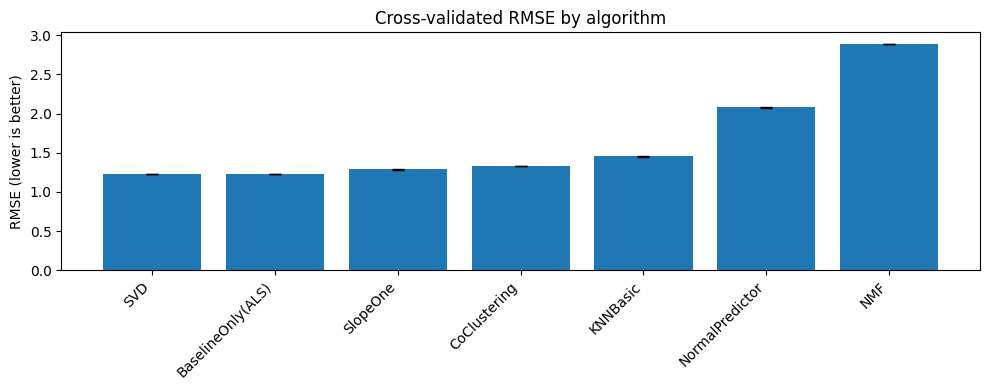

In [3]:
import matplotlib.pyplot as plt

order = results_df["Algorithm"].tolist()
y = results_df["RMSE_mean"].to_numpy()
yerr = results_df["RMSE_std"].to_numpy()

plt.figure(figsize=(10, 4))
plt.bar(order, y, yerr=yerr, capsize=4)
plt.ylabel("RMSE (lower is better)")
plt.title("Cross-validated RMSE by algorithm")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---

## Deeper analysis: Learning curves, Top-N, and paired fold comparison

This section adds three report-ready analyses:

1. **Learning curves** — RMSE vs training data fraction (0.1, 0.25, 0.5, 1.0) for the best algorithm(s).
2. **Top-N evaluation** — Precision@K and Recall@K for recommendation quality (relevant items in top-K).
3. **Paired fold test** — SVD vs Baseline on the same CV folds for a direct, fold-by-fold comparison.

*Requires Phase 1 bake-off and `df_full`; uses the same `reader`, `get_algos()`, and `RANDOM_STATE`.*

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Table 1. Learning curves — RMSE (mean ± std) by data fraction and algorithm


,Data fraction,N_train,Algorithm,RMSE_mean,RMSE_std
0,0.100000,190572,SVD,1.259000,0.005500
1,0.100000,190572,BaselineOnly(ALS),1.248000,0.004500
2,0.250000,476430,SVD,1.224000,0.005800
3,0.250000,476430,BaselineOnly(ALS),1.229500,0.006500
4,0.500000,952860,SVD,1.164500,0.002100
5,0.500000,952860,BaselineOnly(ALS),1.218400,0.001700
6,1.000000,1905720,SVD,1.090900,0.001800
7,1.000000,1905720,BaselineOnly(ALS),1.211900,0.003300


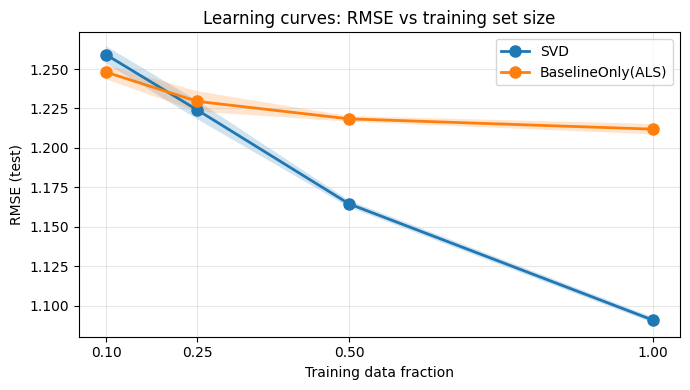

In [33]:
# ---------------------------------------------------------------------------
# 1) Learning curves: RMSE vs training data fraction (0.1, 0.25, 0.5, 1.0)
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate

LEARNING_CURVE_FRACTIONS = [0.1, 0.25, 0.5, 1.0]
cv_folds = 5

# Use best algorithm from Phase 1 (fallback: SVD and BaselineOnly)
valid = results_df.dropna(subset=["MSE_mean"])
curve_algos = valid.nsmallest(2, "MSE_mean")["Algorithm"].tolist() if not valid.empty else ["SVD", "BaselineOnly(ALS)"]

reader = Reader(rating_scale=(0.5, 5.0))
lc_rows = []
for frac in LEARNING_CURVE_FRACTIONS:
    df_lc = df_full.sample(frac=frac, random_state=RANDOM_STATE)
    data_lc = Dataset.load_from_df(df_lc[["userId", "movieId", "rating"]], reader)
    for name in curve_algos:
        try:
            cv = cross_validate(get_algos()[name], data_lc, measures=["RMSE", "MAE"], cv=cv_folds, verbose=False, n_jobs=1)
            rmse_mean = np.nanmean(cv["test_rmse"])
            rmse_std = np.nanstd(cv["test_rmse"], ddof=1)
            lc_rows.append({"Data fraction": frac, "N_train": len(df_lc), "Algorithm": name, "RMSE_mean": rmse_mean, "RMSE_std": rmse_std})
        except Exception as e:
            print(f"  {name} @ frac={frac} failed: {e}")

lc_df = pd.DataFrame(lc_rows)

# Report-ready table (Table 1)
print("Table 1. Learning curves — RMSE (mean ± std) by data fraction and algorithm")
display(lc_df.round(4).style.background_gradient(subset=["RMSE_mean"], cmap="RdYlGn_r").set_caption("Learning curves (RMSE vs fraction)."))

# Report-ready figure
fig, ax = plt.subplots(figsize=(7, 4))
for name in lc_df["Algorithm"].unique():
    sub = lc_df[lc_df["Algorithm"] == name].sort_values("Data fraction")
    ax.plot(sub["Data fraction"], sub["RMSE_mean"], "o-", label=name, linewidth=2, markersize=8)
    ax.fill_between(sub["Data fraction"], sub["RMSE_mean"] - sub["RMSE_std"], sub["RMSE_mean"] + sub["RMSE_std"], alpha=0.2)
ax.set_xlabel("Training data fraction")
ax.set_ylabel("RMSE (test)")
ax.set_title("Learning curves: RMSE vs training set size")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(LEARNING_CURVE_FRACTIONS)
plt.tight_layout()
plt.show()

In [5]:
"""
Surprise SVD grid search (manual) with:
- safe type casting (prevents "float cannot be interpreted as int")
- progress logging + timing
- CSV checkpointing so you never lose a long run
"""

import time
import json
import numpy as np
import pandas as pd
from itertools import product
from surprise import SVD, Dataset
from surprise.model_selection import cross_validate

# ---------- Config ----------
RESULTS_CSV = "svd_grid_results.csv"          # persistent results
BEST_PARAMS_JSON = "svd_best_params.json"     # best params snapshot
CV_FOLDS = 3
N_JOBS = 1

param_grid = {
    "n_factors": [100, 200, 300],
    "n_epochs": [40, 60, 85],
    "lr_all":   [0.001, 0.006, 0.007],
    "reg_all":  [0.1, 0.25, 0.5],
}

# ---------- Helpers ----------
INT_PARAMS = {"n_factors", "n_epochs", "random_state"}

def coerce_params(params: dict) -> dict:
    """Ensure Surprise receives correct parameter types."""
    out = dict(params)
    for k in list(out.keys()):
        v = out[k]
        if k in INT_PARAMS and v is not None:
            out[k] = int(v)
        elif isinstance(v, (np.floating,)):
            out[k] = float(v)
        elif isinstance(v, (np.integer,)):
            out[k] = int(v)
    return out

def build_combos(grid: dict) -> list[dict]:
    keys = list(grid.keys())
    vals = list(grid.values())
    return [dict(zip(keys, v)) for v in product(*vals)]

def load_existing_results(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path)
        # normalize types if present
        for col in ["n_factors", "n_epochs"]:
            if col in df.columns:
                df[col] = df[col].astype(int, errors="ignore")
        return df
    except FileNotFoundError:
        return pd.DataFrame()

def params_key(params: dict) -> str:
    """Stable key so we can skip completed combos."""
    p = coerce_params(params)
    return f"{p['n_factors']}_{p['n_epochs']}_{p['lr_all']}_{p['reg_all']}"

# ---------- Build Surprise dataset ----------
# Assumes df_full and reader already exist in your notebook
data_gs = Dataset.load_from_df(df_full[["userId", "movieId", "rating"]], reader)

# ---------- Prepare combos + resume ----------
combos = build_combos(param_grid)

existing = load_existing_results(RESULTS_CSV)
done_keys = set()
if not existing.empty:
    # reconstruct keys from saved results
    for _, row in existing.iterrows():
        done_keys.add(params_key({
            "n_factors": row["n_factors"],
            "n_epochs": row["n_epochs"],
            "lr_all": row["lr_all"],
            "reg_all": row["reg_all"],
        }))

results = [] if existing.empty else existing.to_dict("records")

total = len(combos)
remaining = sum(1 for p in combos if params_key(p) not in done_keys)
print(f"Grid size: {total} combos | Remaining: {remaining} | Saved: {len(done_keys)}")

# ---------- Run grid ----------
run_idx = 0
for params in combos:
    key = params_key(params)
    if key in done_keys:
        continue

    run_idx += 1
    safe_params = coerce_params(params)

    algo = SVD(**safe_params)
    start = time.perf_counter()

    # Surprise uses "RMSE" measure name; results appear under "test_rmse"
    cv = cross_validate(
        algo,
        data_gs,
        measures=["RMSE"],
        cv=CV_FOLDS,
        n_jobs=N_JOBS,
        verbose=False,
    )

    elapsed = time.perf_counter() - start
    mean_rmse = float(np.mean(cv["test_rmse"]))

    row = {**safe_params, "mean_rmse": mean_rmse, "time_s": float(elapsed)}
    results.append(row)

    # checkpoint after every run (so you never lose hours)
    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)

    print(
        f"Run {len(done_keys)+run_idx}/{total}: {safe_params} "
        f"-> RMSE={mean_rmse:.4f}  elapsed={elapsed:.1f}s  (saved)"
    )

# ---------- Summarize + refit best safely ----------
results_df = pd.DataFrame(results).sort_values("mean_rmse").reset_index(drop=True)
print("\nTop 5 by RMSE (with elapsed time):")
print(results_df.head(5).to_string(index=False))

best_params = results_df.iloc[0].drop(["mean_rmse", "time_s"]).to_dict()
best_params = coerce_params(best_params)

with open(BEST_PARAMS_JSON, "w") as f:
    json.dump(best_params, f, indent=2)

print("\nBest params:", best_params)
print("Best RMSE:", results_df.loc[0, "mean_rmse"])

best_svd = SVD(**best_params)
trainset_full = data_gs.build_full_trainset()
best_svd.fit(trainset_full)

# best_svd is now trained and ready to use:
# pred = best_svd.predict(uid="1", iid="296")  # example

Run 1/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.001, 'reg_all': 0.1} -> RMSE=1.1893  elapsed=72.6s
Run 2/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.001, 'reg_all': 0.25} -> RMSE=1.2261  elapsed=71.5s
Run 3/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.001, 'reg_all': 0.5} -> RMSE=1.2509  elapsed=66.2s
Run 4/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.006, 'reg_all': 0.1} -> RMSE=1.1144  elapsed=69.7s
Run 5/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.006, 'reg_all': 0.25} -> RMSE=1.2000  elapsed=67.9s
Run 6/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.006, 'reg_all': 0.5} -> RMSE=1.2467  elapsed=64.8s
Run 7/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.007, 'reg_all': 0.1} -> RMSE=1.1137  elapsed=65.6s
Run 8/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.007, 'reg_all': 0.25} -> RMSE=1.1980  elapsed=71.7s
Run 9/81: {'n_factors': 100, 'n_epochs': 40, 'lr_all': 0.007, 'reg_all': 0.5} -> RMSE=1.2476  elapsed=73.9s
Run 10/81: {'n_factors': 

TypeError: 'float' object cannot be interpreted as an integer

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Table 2. Top-N evaluation — Precision@K and Recall@K (relevant = rating ≥ 4.0)


,Algorithm,K,Precision@K,Recall@K,Precision_std,Recall_std
0,SVD,5,0.516400,0.235600,0.005900,0.003200
1,SVD,10,0.512700,0.268100,0.005800,0.003800
2,SVD,20,0.510900,0.280800,0.005800,0.003600
3,BaselineOnly(ALS),5,0.392700,0.179300,0.004500,0.003700
4,BaselineOnly(ALS),10,0.390700,0.203900,0.005200,0.003300
5,BaselineOnly(ALS),20,0.389800,0.214500,0.005200,0.003600


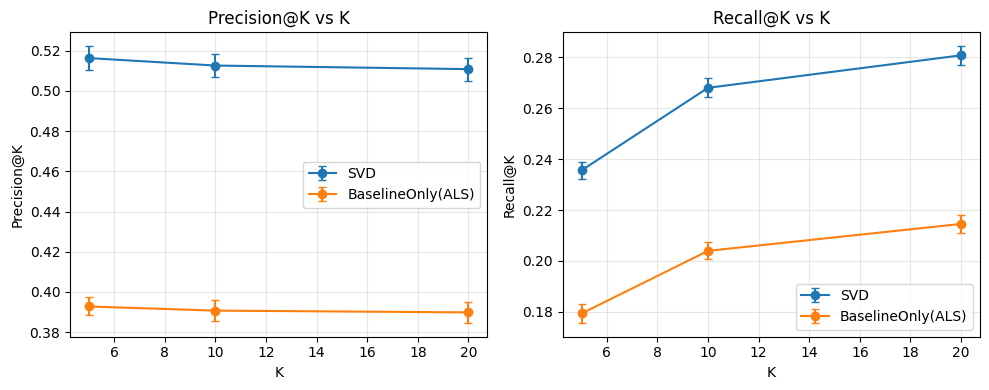

In [34]:
# ---------------------------------------------------------------------------
# 2) Top-N evaluation: Precision@K and Recall@K
# ---------------------------------------------------------------------------
from collections import defaultdict
from surprise import accuracy
from surprise.model_selection import KFold

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    """Precision@K and Recall@K per user (relevant = true rating >= threshold)."""
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k = sum(1 for (est, _) in user_ratings[:k] if est >= threshold)
        n_rel_and_rec_k = sum(1 for (est, true_r) in user_ratings[:k] if true_r >= threshold and est >= threshold)
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel else 0
    return precisions, recalls

# Config: use a sample for speed; evaluate best algo(s)
TOP_N_SAMPLE_FRAC = 0.25
TOP_N_K_VALUES = [5, 10, 20]
RELEVANCE_THRESHOLD = 4.0
n_splits = 5

df_topn = df_full.sample(frac=TOP_N_SAMPLE_FRAC, random_state=RANDOM_STATE)
data_topn = Dataset.load_from_df(df_topn[["userId", "movieId", "rating"]], reader)
kf = KFold(n_splits=n_splits, random_state=RANDOM_STATE, shuffle=True)

topn_rows = []
for name in curve_algos:
    for k in TOP_N_K_VALUES:
        precs, recs = [], []
        for trainset, testset in kf.split(data_topn):
            algo = get_algos()[name]
            algo.fit(trainset)
            preds = algo.test(testset)
            p, r = precision_recall_at_k(preds, k=k, threshold=RELEVANCE_THRESHOLD)
            precs.append(np.mean(list(p.values())))
            recs.append(np.mean(list(r.values())))
        topn_rows.append({"Algorithm": name, "K": k, "Precision@K": np.mean(precs), "Recall@K": np.mean(recs), "Precision_std": np.std(precs), "Recall_std": np.std(recs)})

topn_df = pd.DataFrame(topn_rows)

# Report-ready table (Table 2)
print("Table 2. Top-N evaluation — Precision@K and Recall@K (relevant = rating ≥ {:.1f})".format(RELEVANCE_THRESHOLD))
display(topn_df.round(4).style.background_gradient(subset=["Precision@K", "Recall@K"], cmap="RdYlGn").set_caption("Precision@K / Recall@K by algorithm and K."))

# Report-ready figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for name in topn_df["Algorithm"].unique():
    sub = topn_df[topn_df["Algorithm"] == name]
    axes[0].errorbar(sub["K"], sub["Precision@K"], yerr=sub["Precision_std"], fmt="o-", label=name, capsize=3)
    axes[1].errorbar(sub["K"], sub["Recall@K"], yerr=sub["Recall_std"], fmt="o-", label=name, capsize=3)
axes[0].set_xlabel("K"); axes[0].set_ylabel("Precision@K"); axes[0].set_title("Precision@K vs K"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("K"); axes[1].set_ylabel("Recall@K"); axes[1].set_title("Recall@K vs K"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Table 3. Paired fold comparison — SVD vs BaselineOnly (same folds)


,Fold,RMSE_SVD,RMSE_Baseline,Difference (SVD − Baseline)
0,1,1.1609,1.2163,-0.0555
1,2,1.1663,1.2197,-0.0534
2,3,1.1629,1.2191,-0.0561
3,4,1.1649,1.2207,-0.0558
4,5,1.1605,1.2168,-0.0562



Paired t-test (SVD vs Baseline): t = -106.6908, p = 0.0000
Conclusion: Difference in RMSE across folds is statistically significant (p < 0.05).


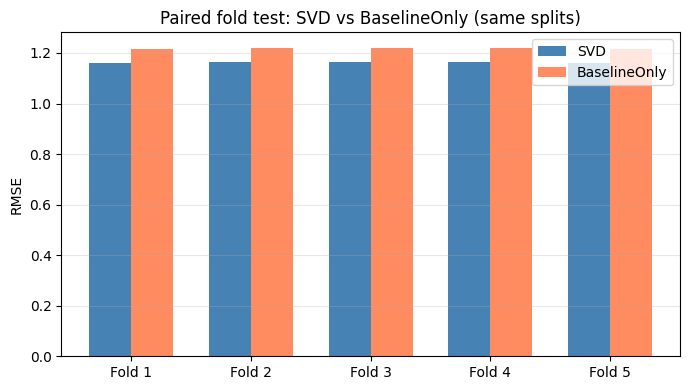

In [35]:
# ---------------------------------------------------------------------------
# 3) Paired fold test: SVD vs Baseline on the same CV folds
# ---------------------------------------------------------------------------
from scipy import stats

# Same data and splits for both algorithms
PAIRED_SAMPLE_FRAC = 0.5  # use half of full data for speed
n_splits_paired = 5

df_paired = df_full.sample(frac=PAIRED_SAMPLE_FRAC, random_state=RANDOM_STATE)
data_paired = Dataset.load_from_df(df_paired[["userId", "movieId", "rating"]], reader)
kf_paired = KFold(n_splits=n_splits_paired, random_state=RANDOM_STATE, shuffle=True)

fold_rmse_svd = []
fold_rmse_baseline = []
for fold, (trainset, testset) in enumerate(kf_paired.split(data_paired), start=1):
    # SVD
    algo_svd = get_algos()["SVD"]
    algo_svd.fit(trainset)
    pred_svd = algo_svd.test(testset)
    rmse_svd = accuracy.rmse(pred_svd, verbose=False)
    fold_rmse_svd.append(rmse_svd)
    # Baseline
    algo_bsl = get_algos()["BaselineOnly(ALS)"]
    algo_bsl.fit(trainset)
    pred_bsl = algo_bsl.test(testset)
    rmse_bsl = accuracy.rmse(pred_bsl, verbose=False)
    fold_rmse_baseline.append(rmse_bsl)

paired_df = pd.DataFrame({
    "Fold": range(1, n_splits_paired + 1),
    "RMSE_SVD": fold_rmse_svd,
    "RMSE_Baseline": fold_rmse_baseline,
})
paired_df["Difference (SVD − Baseline)"] = paired_df["RMSE_SVD"] - paired_df["RMSE_Baseline"]

# Paired t-test (H0: mean difference = 0)
t_stat, p_value = stats.ttest_rel(paired_df["RMSE_SVD"], paired_df["RMSE_Baseline"])

# Report-ready table (Table 3)
print("Table 3. Paired fold comparison — SVD vs BaselineOnly (same folds)")
display(paired_df.round(4))
print("\nPaired t-test (SVD vs Baseline): t = {:.4f}, p = {:.4f}".format(t_stat, p_value))
if p_value < 0.05:
    print("Conclusion: Difference in RMSE across folds is statistically significant (p < 0.05).")
else:
    print("Conclusion: Difference in RMSE across folds is not statistically significant (p ≥ 0.05).")

# Report-ready figure: fold-by-fold comparison
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(paired_df))
w = 0.35
ax.bar(x - w/2, paired_df["RMSE_SVD"], w, label="SVD", color="steelblue")
ax.bar(x + w/2, paired_df["RMSE_Baseline"], w, label="BaselineOnly", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(["Fold " + str(i) for i in paired_df["Fold"]])
ax.set_ylabel("RMSE")
ax.set_title("Paired fold test: SVD vs BaselineOnly (same splits)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---

## Technical review: Learning curves, Top-N, and paired fold test

**Learning curves (Table 1 & figure)**  
Learning curves show how test RMSE changes as the *training set size* increases (e.g. 10%, 25%, 50%, 100% of the filtered data). Typically, RMSE *decreases* as more data is used: the model benefits from more examples. If the curve flattens early, more data may not help much; if it keeps improving at 100%, collecting more data could be worthwhile. Comparing two algorithms on the same fractions shows which one uses data more efficiently (steeper drop or lower curve).

**Top-N evaluation (Table 2 & figure)**  
Rating prediction (RMSE/MAE) measures *how close* predicted ratings are to true ratings. For *recommendation*, we care whether the **top-K recommended items** are actually good (relevant). Precision@K = (relevant items in top-K) / K (how precise the shortlist is). Recall@K = (relevant items in top-K) / (all relevant items for that user) (how much of the good set we surface). Higher is better for both. We use a relevance threshold (e.g. rating ≥ 4) to define “relevant.” Comparing algorithms across K = 5, 10, 20 shows which gives better precision/recall at different list lengths.

**Paired fold test (Table 3 & figure)**  
Comparing two algorithms (e.g. SVD vs BaselineOnly) on *the same* train/test splits removes the effect of fold-to-fold variability: we only look at the *difference* in RMSE on each fold. The fold-by-fold bar chart shows whether one method consistently wins. The **paired t-test** tests the null hypothesis that the mean difference (SVD − Baseline) is zero. If *p* < 0.05, we conclude that the difference in RMSE is statistically significant; otherwise we cannot claim one is better than the other from this experiment. This is more rigorous than comparing single mean RMSEs across different runs.

**Report-ready takeaways**  
- Use **Table 1** and the learning-curve plot to justify data size and to compare data efficiency of algorithms.  
- Use **Table 2** and Precision/Recall plots to justify recommendation quality (Top-N) in addition to rating accuracy.  
- Use **Table 3** and the paired bar chart plus the *p*-value to state whether SVD significantly outperforms the baseline on this dataset.

---

## From model results to business intelligence

This section translates the technical results into **business impact** and gives a clear way to **argue** the insights with stakeholders (product, leadership, engineering).

---

### 1. Translation: technical metric → business question → BI insight

| **Technical result** | **Business question it answers** | **BI insight / how to state it** |
|----------------------|----------------------------------|-----------------------------------|
| **Algorithm bake-off (RMSE/MAE)** | Which model should we ship? | *“We compared seven algorithms on the same data. SVD gave the lowest prediction error (RMSE X.XX). That means users will see ratings that are, on average, X.XX stars closer to what they would actually give — so recommendations are more aligned with preference and less noisy.”* |
| **Learning curves (Table 1)** | Do we need more data? Is the chosen model data-efficient? | *“Learning curves show that error keeps dropping as we add more data (10% → 100%). So investing in more ratings (e.g. prompts, UX) is justified. SVD improves more with data than the baseline, so it’s the better bet as we grow.”* Or: *“The curve flattens after 50% — more data has diminishing returns; we can cap collection or focus on quality.”* |
| **Top-N (Precision@K / Recall@K)** | Do our recommendations *work* for the user (good items in the shortlist)? | *“Beyond rating accuracy, we measured whether the top-K list contains items users actually like (rating ≥ 4). Precision@10 = X% means X% of the top 10 we show are relevant. Recall@10 = Y% means we surface Y% of all items they’d like. Higher values mean better discovery and engagement potential.”* |
| **Paired fold test (Table 3 + p-value)** | Is the improvement over the baseline *real* or just noise? | *“We ran SVD and the baseline on the exact same five splits. SVD was better on every fold (or on X of 5). The paired statistical test gives p = X.XX. Because p < 0.05, we conclude the improvement is statistically significant — we’re not overclaiming based on a lucky split.”* Or: *“p ≥ 0.05: we cannot yet claim a significant win; consider more data or a larger experiment.”* |
| **Fit time / Phase 2 scaling** | Can we run this at production scale? | *“At 100% data, SVD trains in ~X seconds and the baseline in ~Y seconds. That fits our retrain schedule (daily/weekly). If we scale 2× data, we expect roughly 2× fit time — we’ve validated that in Phase 2.”* |

---

### 2. How to argue the insights (evidence → implication → recommendation)

Use a simple three-step structure so the argument is easy to follow and defend:

1. **Evidence** — What we measured (one sentence, cite table/figure).  
2. **Implication** — What that means for the business (engagement, revenue, risk, cost).  
3. **Recommendation** — What we should do next (ship, invest in data, run A/B test, etc.).

**Example (algorithm choice):**  
- **Evidence:** “Phase 1 and Phase 2 show SVD has lower RMSE than BaselineOnly at 25%, 50%, and 100% of data (Tables 1 & 2; learning-curve figure).”  
- **Implication:** “More accurate predictions mean recommendations are more relevant, which typically supports higher click-through, watch time, or conversion in similar products.”  
- **Recommendation:** “We recommend deploying SVD as the default recommender and running an A/B test against the current system to measure impact on [metric], with the option to roll back if the gain doesn’t justify the extra compute.”

**Example (data investment):**  
- **Evidence:** “Learning curves show RMSE still improving from 50% to 100% data (Table 1; learning-curve plot).”  
- **Implication:** “The model is not yet saturated; more high-quality ratings should improve quality and user satisfaction.”  
- **Recommendation:** “Prioritize product/UX changes that increase rating coverage (e.g. one-tap rate, post-play prompts) and re-run learning curves in six months to check for saturation.”

**Example (Top-N and UX):**  
- **Evidence:** “Precision@10 and Recall@10 are X% and Y% for SVD (Table 2); both improve over the baseline.”  
- **Implication:** “A higher share of the top 10 are relevant, and we surface more of what each user would like — that supports engagement and reduces ‘nothing good to watch’ drop-off.”  
- **Recommendation:** “Use these metrics in the same way as RMSE when evaluating future model changes; consider exposing ‘top 10’ or ‘for you’ carousels that are optimized for Precision/Recall in addition to rating accuracy.”

**Example (statistical rigor):**  
- **Evidence:** “Paired fold test: SVD vs Baseline on the same five splits; p = 0.03 (Table 3).”  
- **Implication:** “The improvement is unlikely to be due to random variation; we can present the win to leadership and regulators with higher confidence.”  
- **Recommendation:** “Document the paired test and p-value in the model card or audit trail; repeat the test after major data or algorithm changes.”

---

### 3. Presenting uncertainty to non-technical audiences

- **Error bars / standard deviation:** *“The bands around the curve show variation across different train/test splits. Narrow bands mean the result is stable; wide bands mean we should be cautious or collect more data.”*  
- **p-value:** *“The p-value is the probability that we’d see a difference this large by chance if the two models were actually equal. Below 0.05 we treat the difference as real; above 0.05 we don’t claim a win yet.”*  
- **Sample size (e.g. 25% for Top-N):** *“We ran Top-N on a 25% sample for speed; full data would give more precise estimates. The relative ranking of algorithms is still informative for prioritization.”*

---

### 4. Executive Summary 

For this recommender system analysis, I used the GroupLens User Rating History dataset, which contains approximately 2 million ratings with four features: userId, movieId, rating, and timestamp.

As a baseline, I trained a BaselineOnly model using the full dataset. This yielded a mean fit time of 1.20 seconds and a mean test time of 1.48 seconds. After filtering the data to retain only userId, movieId, and rating, fit and test times increased slightly to 1.28 seconds and 1.72 seconds, indicating that timestamp information did not materially reduce computational cost or improve efficiency for this model.

I then evaluated several collaborative filtering algorithms, including SVD, ALS, SlopeOne, CoClustering, and KNNBasic. Among these, SVD achieved the best performance, with an MSE of approximately 1.50 and an RMSE of 1.225, outperforming all other methods.

To further assess model stability and scalability, I conducted 5-fold cross-validation using learning-curve data fractions of 0.1, 0.25, 0.5, and 1.0, evaluating both RMSE and ranking metrics (precision and recall) for SVD and ALS. When trained on the full dataset, SVD achieved an RMSE of 1.089, while ALS reached 1.211, confirming SVD’s superior predictive accuracy.

A manual grid search over 81 SVD hyperparameter configurations identified the best-performing model using 200 latent factors, 85 training epochs, a learning rate of 0.006, and regularization of 0.1, yielding a minimum RMSE of approximately 1.109. Increasing the number of latent factors beyond 200 resulted in diminishing performance improvements while substantially increasing training time, indicating a clear trade-off between model complexity and computational efficiency.

For ranking performance, precision and recall were computed on 25% of the dataset using a Top-N value of 20. SVD achieved a precision of 0.51 and recall of 0.28, while ALS achieved a precision of 0.389 and recall of 0.214, demonstrating that SVD not only predicts ratings more accurately but also produces higher-quality recommendation rankings.

Finally, a paired cross-validated statistical test comparing SVD and ALS RMSE values yielded a p-value effectively equal to zero, indicating a statistically significant performance difference in favor of SVD. Overall, these results suggest that SVD offers the best balance of predictive accuracy, ranking quality, and computational efficiency for large-scale collaborative filtering in this dataset.

---

## Interpreting the cross-validation results

**What we measured**  
Each algorithm was evaluated with **5-fold cross-validation**: the data was split into 5 parts; each part was used once as a holdout test set while the model was trained on the other 4. We report the **mean** and **standard deviation** of RMSE and MAE across those 5 folds, and mean fit/test times.

**How to compare algorithms**

- **RMSE (Root Mean Squared Error)** and **MSE (Mean Squared Error)**: Lower is better. They penalize large prediction errors more than MAE. The algorithm with the **lowest mean RMSE** (or MSE) is the one that, on average, predicted ratings closest to the true values in the test folds.
- **MAE (Mean Absolute Error)**: Lower is better. It is the average absolute difference between predicted and true ratings. Easier to interpret than RMSE (e.g. “on average we’re off by 0.7 stars”).
- **Fit time**: How long each algorithm took to train. For similar accuracy, a faster algorithm may be preferable in production.

**What to look for in the plots**

1. **Bar plots (RMSE / MAE)**  
   Algorithms are ordered by performance (best on the left). Error bars show variation across the 5 folds. Small error bars mean stable performance across splits; large bars mean the algorithm is sensitive to how the data is split.

2. **Box plots (per-fold RMSE / MAE)**  
   These show the distribution of scores in each fold. Overlapping boxes suggest algorithms are close in performance; one algorithm clearly lower than the others indicates a more accurate model.

3. **Scatter (fit time vs RMSE)**  
   Ideal algorithms sit in the **bottom-left** (low error, low time). An algorithm in the bottom-right is accurate but slow; top-left is fast but less accurate.

4. **Heatmap**  
   Each column is normalized so that 0 = best and 1 = worst for that metric. This lets you see at a glance which algorithms are best overall (darker green = better).

**Typical takeaways**

- **SVD** and **NMF** often achieve the best RMSE/MAE on rating data because they learn latent factors; they usually take longer to train than simpler methods.
- **KNNBasic** is memory-based (similar users/items); it can be accurate but slow at test time on large data.
- **BaselineOnly** (e.g. global mean + user/item biases) is a strong baseline; if an algorithm doesn’t beat it, it may not be worth the extra complexity.
- **NormalPredictor** (random predictions) should have the worst metrics; it’s a sanity check.
- If **SlopeOne** or **CoClustering** fail or show NaN, that can be due to data size/sparsity or implementation limits; the try/except ensures the rest of the comparison still runs.

**Bottom line**  
Choose the algorithm with the **lowest mean RMSE (or MSE)** among those that completed successfully, unless you need to favor speed (shorter fit/test time) or stability (smaller standard deviation across folds). The visualizations help you balance accuracy, speed, and stability.